<a href="https://colab.research.google.com/github/AliciaW2026/MachineLearning-Assignments/blob/main/Assignment_14_Ethical_AI_Fairness_Explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 14: Ethical AI, Fairness, and Explainability

**Student Name:** Alicia Wright  
**Course:** Machine Learning / Data Science  
**Assignment:** Assignment 14  

## Project Overview

This notebook builds and evaluates a machine learning model with a focus on ethical AI, fairness, and explainability. The goal is to train a logistic regression model, evaluate model performance, analyze fairness across a sensitive attribute, and explain model predictions using SHAP and LIME.

The project uses the **Titanic dataset**, which is a public dataset commonly used for machine learning classification tasks. The target variable is whether a passenger survived, and the sensitive attribute used for fairness analysis is **sex**.


## 1. Install and Import Required Libraries

This section installs and imports the libraries needed for data processing, machine learning, fairness analysis, visualization, and explainability.


In [1]:
# Install required packages
!pip install fairlearn shap lime seaborn -q

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Fairness analysis
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, true_positive_rate

# Explainability
import shap
from lime.lime_tabular import LimeTabularExplainer

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 18.6 MB/s eta 0:00:00


## 2. Load the Dataset

The Titanic dataset includes passenger information such as sex, age, passenger class, fare, and survival outcome. This dataset is appropriate for fairness analysis because it contains demographic information that can be used as a sensitive attribute.


In [2]:
# Load Titanic dataset from seaborn
# This is a public dataset and works directly in Google Colab.
df = sns.load_dataset('titanic')

# Show the first few rows
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Check dataset shape and column information
print('Dataset shape:', df.shape)
df.info()


Dataset shape: (891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
# Check missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values


,0
deck,688
age,177
embarked,2
embark_town,2
sex,0
pclass,0
survived,0
fare,0
parch,0
sibsp,0


## 3. Dataset Preparation and Preprocessing

For this project:

- **Target variable (y):** `survived`
- **Sensitive attribute:** `sex`
- **Features (X):** passenger class, sex, age, siblings/spouses aboard, parents/children aboard, fare, embark town, and whether the passenger was alone

Rows with missing values in the selected columns are removed to keep the preprocessing clear and reliable.


In [5]:
# Select relevant columns
selected_columns = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embark_town', 'alone']
df_model = df[selected_columns].copy()

# Drop rows with missing values in selected columns
df_model = df_model.dropna()

# Define target, features, and sensitive attribute
y = df_model['survived']
X = df_model.drop(columns=['survived'])
sensitive_feature = df_model['sex']

print('Prepared dataset shape:', df_model.shape)
X.head()


Prepared dataset shape: (712, 9)


,pclass,sex,age,sibsp,parch,fare,embark_town,alone
0,3,male,22.0,1,0,7.2500,Southampton,False
1,1,female,38.0,1,0,71.2833,Cherbourg,False
2,3,female,26.0,0,0,7.9250,Southampton,True
3,1,female,35.0,1,0,53.1000,Southampton,False
4,3,male,35.0,0,0,8.0500,Southampton,True


In [6]:
# Identify categorical and numeric features
categorical_features = ['sex', 'embark_town', 'alone']
numeric_features = ['pclass', 'age', 'sibsp', 'parch', 'fare']

# Create preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)


## 4. Train-Test Split

The dataset is split into training and testing sets. The sensitive feature is also split so that fairness metrics can be calculated on the test set.


In [7]:
# Split the data
X_train, X_test, y_train, y_test, sensitive_train, sensitive_test = train_test_split(
    X, y, sensitive_feature,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print('Training set size:', X_train.shape)
print('Testing set size:', X_test.shape)


Training set size: (534, 8)
Testing set size: (178, 8)


## 5. Train Logistic Regression Model

A logistic regression model is used because it is a clear and interpretable classification model. This makes it appropriate for ethical AI and fairness analysis.


In [8]:
# Build the model pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Train the model
model.fit(X_train, y_train)

# Generate predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print('Model training complete.')


Model training complete.


## 6. Model Evaluation

The model is evaluated using accuracy, confusion matrix, and classification report.


In [11]:
# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)

# Classification report
print('Classification Report:')
print(classification_report(y_test, y_pred))


Accuracy: 0.7978
Confusion Matrix:
[[90 16]
 [20 52]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       106
           1       0.76      0.72      0.74        72

    accuracy                           0.80       178
   macro avg       0.79      0.79      0.79       178
weighted avg       0.80      0.80      0.80       178



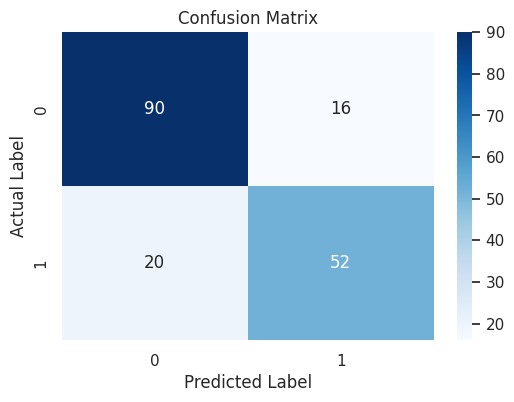

In [12]:
# Visualize confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()


## 7. Fairness Analysis with Fairlearn

This section analyzes whether the model performs differently across groups based on the sensitive attribute `sex`.

The fairness metrics used are:

- **Selection Rate:** How often the model predicts the positive class.
- **False Positive Rate:** How often the model incorrectly predicts survival when the actual result was not survival.
- **True Positive Rate:** How often the model correctly predicts survival.


In [14]:
# Create MetricFrame for fairness analysis
fairness_metrics = {
    'accuracy': accuracy_score,
    'selection_rate': selection_rate,
    'false_positive_rate': false_positive_rate,
    'true_positive_rate': true_positive_rate
}

metric_frame = MetricFrame(
    metrics=fairness_metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_test
)

print('Overall Metrics:')
display(metric_frame.overall)

print('Metrics by Sensitive Group:')
display(metric_frame.by_group)


Overall Metrics:


,0
accuracy,0.797753
selection_rate,0.382022
false_positive_rate,0.150943
true_positive_rate,0.722222


Metrics by Sensitive Group:


,accuracy,selection_rate,false_positive_rate,true_positive_rate
sex,,,,
female,0.772727,0.848485,0.647059,0.918367
male,0.812500,0.107143,0.056180,0.304348


In [15]:
# Convert fairness metrics to DataFrame for visualization
fairness_df = metric_frame.by_group.reset_index()
fairness_df


,sex,accuracy,selection_rate,false_positive_rate,true_positive_rate
0,female,0.772727,0.848485,0.647059,0.918367
1,male,0.812500,0.107143,0.056180,0.304348


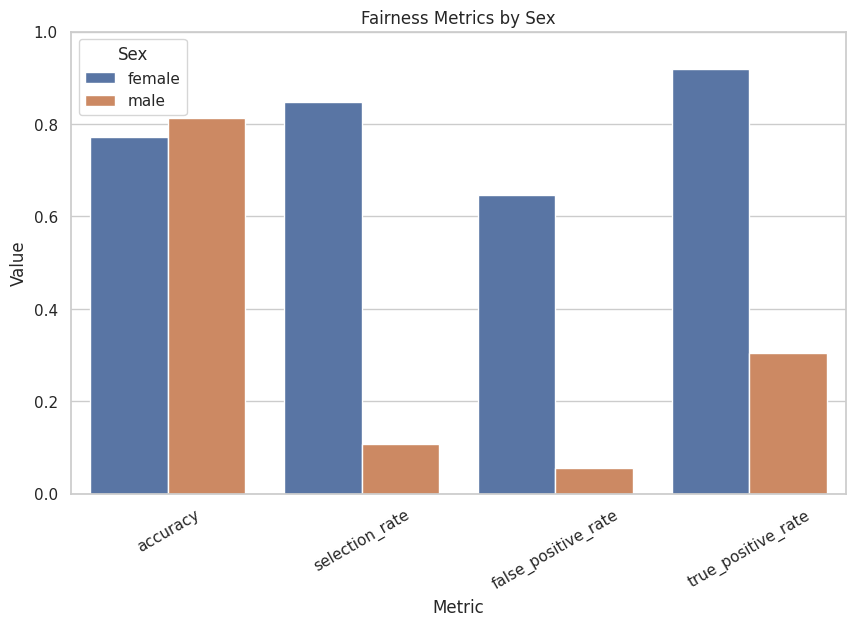

In [16]:
# Plot fairness metrics by group
fairness_df_plot = fairness_df.melt(id_vars='sex', var_name='Metric', value_name='Value')

plt.figure(figsize=(10, 6))
sns.barplot(data=fairness_df_plot, x='Metric', y='Value', hue='sex')
plt.title('Fairness Metrics by Sex')
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.legend(title='Sex')
plt.show()


### Fairness Interpretation

The fairness metrics allow us to compare how the model behaves across male and female passengers. If selection rates, false positive rates, or true positive rates are very different between groups, this may indicate potential bias or unequal model performance. These differences should be investigated before using the model in a real-world decision-making setting.


## 8. Prepare Data for SHAP and LIME

SHAP and LIME require transformed numerical data. The preprocessing pipeline is used to transform the training and testing data into the format used by the logistic regression model.


In [17]:
# Transform data for explainability tools
X_train_transformed = model.named_steps['preprocessor'].transform(X_train)
X_test_transformed = model.named_steps['preprocessor'].transform(X_test)

# Get feature names after preprocessing
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

# Convert to DataFrame for easier viewing
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)

X_train_transformed_df.head()


,num__pclass,num__age,num__sibsp,num__parch,num__fare,cat__sex_female,cat__sex_male,cat__embark_town_Cherbourg,cat__embark_town_Queenstown,cat__embark_town_Southampton,cat__alone_False,cat__alone_True
0,0.918856,-0.720922,-0.536440,-0.508621,-0.527328,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,-1.468829,-0.720922,2.623034,1.853148,4.845546,0.0,1.0,0.0,0.0,1.0,1.0,0.0
2,-0.274986,-0.585828,-0.536440,-0.508621,0.854654,0.0,1.0,0.0,0.0,1.0,0.0,1.0
3,-0.274986,-0.315641,0.516718,1.853148,0.182398,0.0,1.0,1.0,0.0,0.0,1.0,0.0
4,-1.468829,-0.315641,0.516718,-0.508621,0.474344,0.0,1.0,1.0,0.0,0.0,1.0,0.0


## 9. SHAP Explainability Analysis

SHAP helps explain which features have the greatest impact on model predictions.

- The **summary plot** shows global feature importance.
- The **waterfall plot** explains one individual prediction.


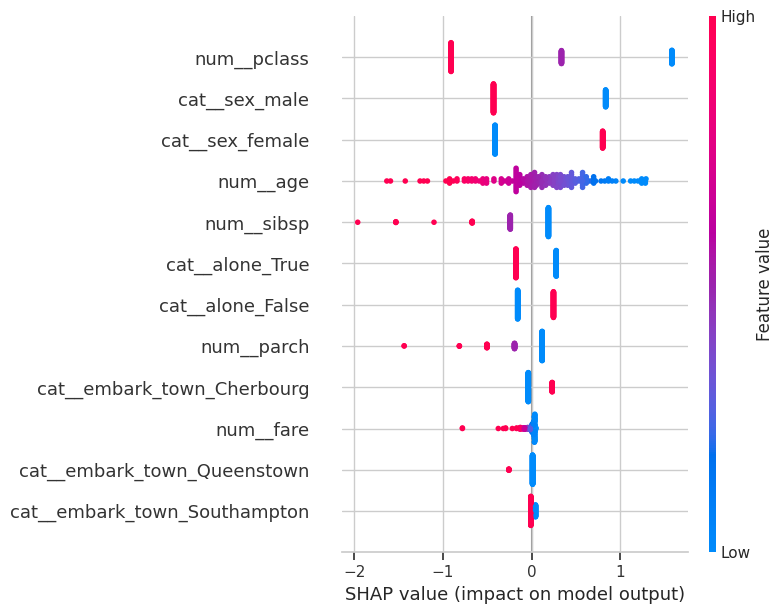

In [18]:
# Create SHAP explainer for logistic regression
classifier = model.named_steps['classifier']
explainer = shap.LinearExplainer(classifier, X_train_transformed_df)
shap_values = explainer(X_test_transformed_df)

# SHAP summary plot for global explainability
shap.summary_plot(shap_values, X_test_transformed_df, feature_names=feature_names)


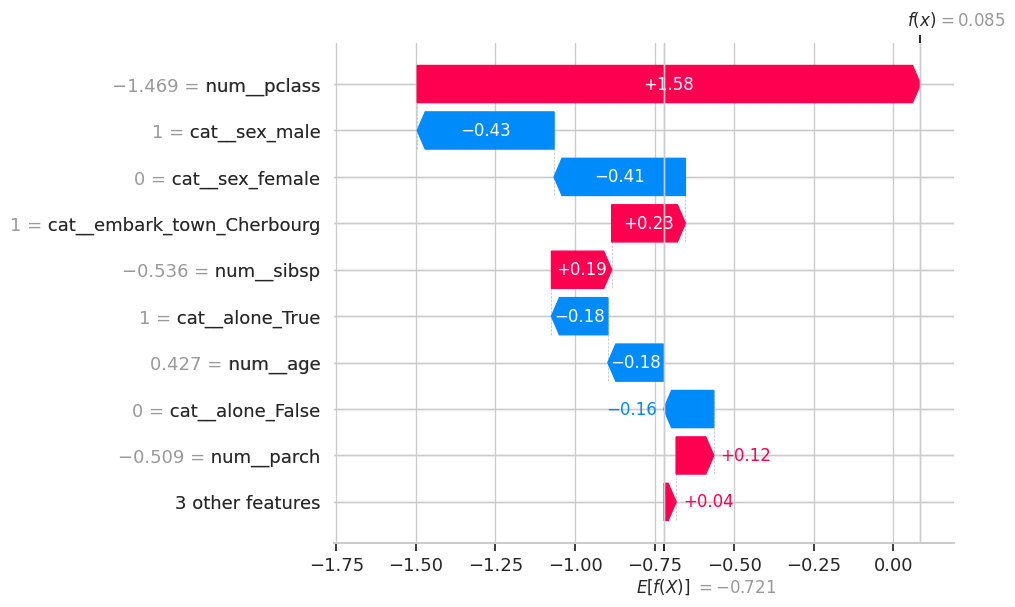

In [19]:
# SHAP waterfall plot for one individual prediction
sample_index = 0
shap.plots.waterfall(shap_values[sample_index])


### SHAP Interpretation

The SHAP summary plot shows which features influenced the model most across all test predictions. Features with stronger SHAP values had a larger effect on whether the model predicted survival. The waterfall plot explains one specific prediction by showing which features pushed the prediction higher or lower.


## 10. LIME Explainability Analysis

LIME explains individual predictions by creating a local explanation around one prediction. This helps make the model more transparent for a single case.


In [20]:
# Create LIME explainer
lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train_transformed_df),
    feature_names=list(feature_names),
    class_names=['Did Not Survive', 'Survived'],
    mode='classification'
)

# Explain one prediction
sample_index = 0
lime_exp = lime_explainer.explain_instance(
    data_row=X_test_transformed_df.iloc[sample_index].values,
    predict_fn=classifier.predict_proba,
    num_features=8
)

# Show LIME explanation in notebook
lime_exp.show_in_notebook(show_table=True)


In [21]:
# Also display LIME explanation as a list for PDF export readability
lime_exp.as_list()


[('cat__sex_female <= 0.00', -0.20630356549875123),
 ('0.00 < cat__sex_male <= 1.00', -0.20570817410139108),
 ('num__pclass <= -1.47', 0.08657616958139557),
 ('0.00 < cat__alone_True <= 1.00', -0.07162189194904708),
 ('cat__alone_False <= 0.00', -0.06902601428403642),
 ('num__parch <= -0.51', 0.0625243114185512),
 ('num__sibsp <= -0.54', 0.061419463615234815),
 ('-0.11 < num__age <= 0.63', -0.04864484300263421)]

### LIME Interpretation

The LIME explanation shows which features contributed most to one individual prediction. This is useful because even if a model performs well overall, we still need to understand why it made a specific prediction.


## 11. Ethical Considerations and Recommendations

This project shows why ethical AI matters. A model can appear accurate overall while still treating different groups differently. When sensitive attributes such as sex or age are involved, fairness analysis helps identify unequal outcomes.

Recommendations for improving fairness include:

1. Use fairness metrics before deploying a model.
2. Compare performance across sensitive groups.
3. Review training data for imbalance or historical bias.
4. Consider removing or adjusting features that create unfair outcomes.
5. Use explainability tools such as SHAP and LIME to make model decisions easier to understand.
6. Continue monitoring the model after deployment.


## 12. Conclusion

This notebook trained a logistic regression model on the Titanic dataset and evaluated the model using performance, fairness, and explainability methods. Fairlearn helped compare model outcomes across groups, while SHAP and LIME helped explain how the model made predictions. The main takeaway is that responsible machine learning requires more than accuracy. Models should also be fair, transparent, and explainable.
